<h2>Conduct thorough time-series analysis to detect and interpret seasonal trends, cyclic patterns, and anomalies over time, applying decomposition techniques and rolling statistics to extract actionable insights from temporal data.</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [5]:
sales = pd.read_csv(r'C:\Users\rutva\Downloads\DS AIML Projects\Daily tasks\Pharmacy management system\archive\sales.csv')

In [6]:
sales

,sale_id,sale_number,customer_name,subtotal,discount_amount,gst_amount,total_amount,payment_method,payment_status,status,created_at
0,1,SALE-2026-07-22-0001,Rajesh Kumar,250.0,12.50,11.88,249.38,Cash,Paid,Completed,2026-07-22 10:30:00
1,2,SALE-2026-07-22-0002,Priya Sharma,180.0,9.00,8.55,179.55,UPI,Paid,Completed,2026-07-22 11:15:00
2,3,SALE-2026-07-22-0003,Amit Patel,320.0,16.00,15.20,319.20,Credit Card,Paid,Completed,2026-07-22 14:45:00
3,4,SALE-2026-07-22-0004,Sunita Gupta,95.0,0.00,4.75,99.75,Cash,Paid,Completed,2026-07-22 16:20:00
4,5,SALE-2026-07-21-0005,Rajesh Kumar,210.0,10.50,9.98,209.48,UPI,Paid,Completed,2026-07-21 09:30:00
5,6,SALE-2026-07-21-0006,Vikram Singh,150.0,7.50,7.13,149.63,Credit Card,Paid,Completed,2026-07-21 12:00:00
6,7,SALE-2026-07-21-0007,Neha Reddy,85.0,0.00,4.25,89.25,Cash,Paid,Completed,2026-07-21 15:30:00
7,8,SALE-2026-07-20-0008,Rahul Verma,420.0,21.00,19.95,418.95,Insurance,Paid,Completed,2026-07-20 10:00:00
8,9,SALE-2026-07-20-0009,Deepa Nair,180.0,9.00,8.55,179.55,UPI,Paid,Completed,2026-07-20 13:45:00
9,10,SALE-2026-07-20-0010,Suresh Krishnan,350.0,17.50,16.63,349.13,Cash,Paid,Completed,2026-07-20 17:00:00


In [8]:
print(sales.columns)

Index(['sale_id', 'sale_number', 'customer_name', 'subtotal',
       'discount_amount', 'gst_amount', 'total_amount', 'payment_method',
       'payment_status', 'status', 'created_at'],
      dtype='object')


In [9]:
sales['created_at'] = pd.to_datetime(sales['created_at'])

In [10]:
daily_sales = sales.groupby(sales['created_at'].dt.date)['total_amount'].sum()

In [11]:
daily_sales.index = pd.to_datetime(daily_sales.index)

In [12]:
daily_sales = daily_sales.asfreq('D', fill_value=0)

In [13]:
df_ts = pd.DataFrame({'total_amount': daily_sales})

In [14]:
df_ts['7D_MA'] = df_ts['total_amount'].rolling(window=7).mean()

In [15]:
df_ts['30D_MA'] = df_ts['total_amount'].rolling(window=30).mean()

In [16]:
df_ts['7D_STD'] = df_ts['total_amount'].rolling(window=7).std()

In [17]:
df_ts['z_score'] = (df_ts['total_amount'] - df_ts['7D_MA']) / (df_ts['7D_STD'] + 1e-5)
anomalies = df_ts[df_ts['z_score'].abs() > 2]

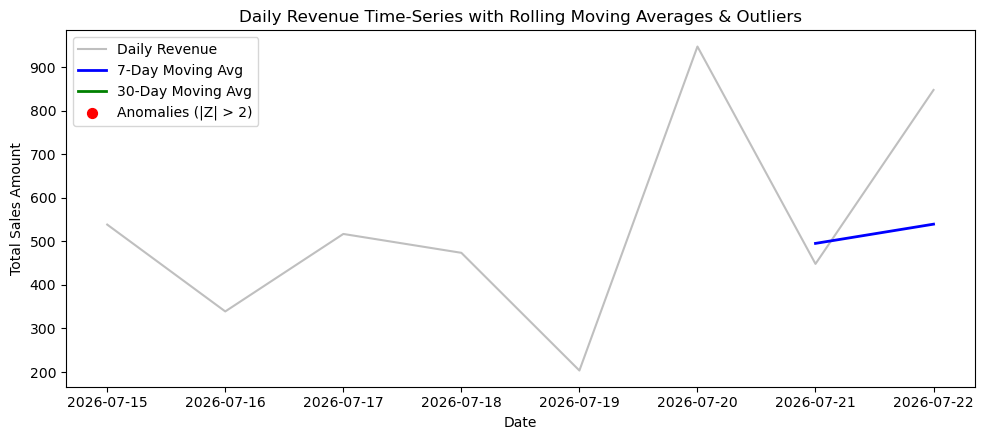

In [22]:
plt.figure(figsize=(10, 4.5))
plt.plot(df_ts.index, df_ts['total_amount'], label='Daily Revenue', alpha=0.5, color='gray')
plt.plot(df_ts.index, df_ts['7D_MA'], label='7-Day Moving Avg', color='blue', linewidth=2)
plt.plot(df_ts.index, df_ts['30D_MA'], label='30-Day Moving Avg', color='green', linewidth=2)
plt.scatter(anomalies.index, anomalies['total_amount'], color='red', label='Anomalies (|Z| > 2)', zorder=5, s=50)


plt.title('Daily Revenue Time-Series with Rolling Moving Averages & Outliers')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.legend()
plt.tight_layout()
plt.show()


<Axes: title={'center': 'Residuals (Unexplained Noise)'}, xlabel='created_at'>

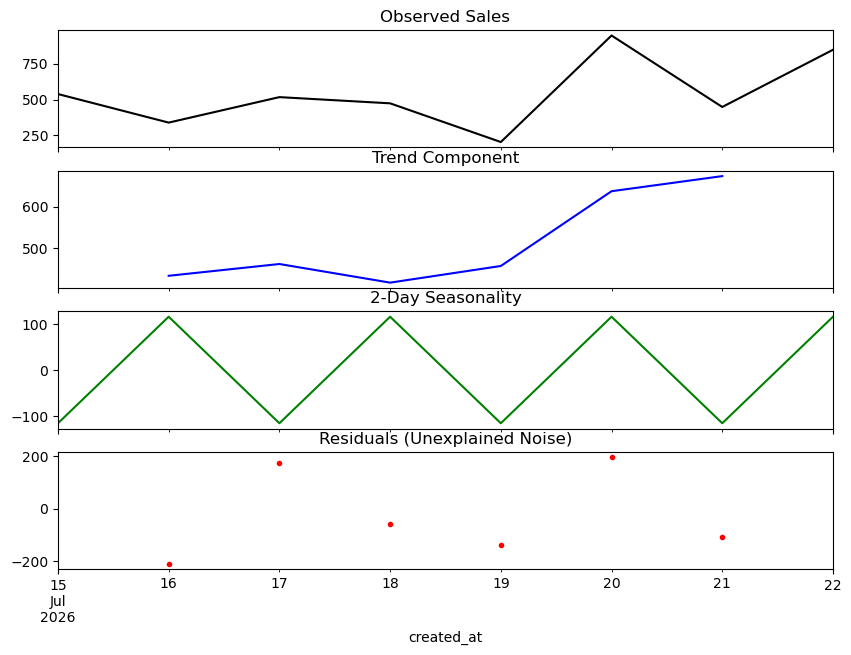

In [25]:
decomp_period = 7 if len(df_ts) >= 14 else 2

decomp = seasonal_decompose(df_ts['total_amount'], model='additive', period=decomp_period)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
decomp.observed.plot(ax=ax1, color='black', title='Observed Sales')
decomp.trend.plot(ax=ax2, color='blue', title='Trend Component')
decomp.seasonal.plot(ax=ax3, color='green', title=f'{decomp_period}-Day Seasonality')
decomp.resid.plot(ax=ax4, color='red', style='.', title='Residuals (Unexplained Noise)')
